In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd

# Load the pre-processed cleaned dataset
df = pd.read_csv("cicids2017_cleaned.csv")

# Clean column headers (removes accidental spaces in names)
df.columns = df.columns.str.strip()

# Display dataset dimensions (rows, columns)
print("Dataset Shape:", df.shape)

# Check class distribution
# print("\nLabel Distribution:")
# print(df['Label'].value_counts())

Dataset Shape: (2520751, 53)


In [3]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Id

In [4]:
print("\nLabel Distribution:")
print(df['Attack Type'].value_counts())


Label Distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [5]:
print("\nLabel Distribution:")
print(df['Attack Type'].value_counts())


Label Distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [6]:
import numpy as np

# CICIDS2017 has some rows where Flow Bytes/s or Flow Packets/s = infinity
# (this happens when Flow Duration = 0, i.e. division by zero when the feature was calculated)
df = df.replace([np.inf, -np.inf], np.nan)

# Drop any row that has a missing value in ANY column
df = df.dropna()

print(df.shape)  # compare this to your original (2520751, 53) to see how many rows you lost

(2520751, 53)


In [7]:
# X = everything the model is allowed to look at to make a prediction (the "inputs")
# y = what we're trying to predict (the "answer key")
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

print(X.shape)
print(y.shape)

(2520751, 52)
(2520751,)


In [8]:
# Turn the 7 detailed categories into just 2: Normal vs Attack
# This is an easier problem to start with before tackling all 7 categories at once
y_binary = y.apply(lambda x: 'Normal Traffic' if x == 'Normal Traffic' else 'ATTACK')

print(y_binary.value_counts())

Attack Type
Normal Traffic    2095057
ATTACK             425694
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1764525, 52)
Test size: (756226, 52)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(y_pred[:10])

['Normal Traffic' 'Normal Traffic' 'ATTACK' 'Normal Traffic'
 'Normal Traffic' 'Normal Traffic' 'Normal Traffic' 'Normal Traffic'
 'Normal Traffic' 'ATTACK']


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

        ATTACK       1.00      1.00      1.00    127708
Normal Traffic       1.00      1.00      1.00    628518

      accuracy                           1.00    756226
     macro avg       1.00      1.00      1.00    756226
  weighted avg       1.00      1.00      1.00    756226



In [14]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 2520751
Duplicate rows: 161


In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
print(top_features)

Bwd Packet Length Std          0.108989
Packet Length Variance         0.101280
Packet Length Std              0.069905
Max Packet Length              0.063764
Average Packet Size            0.054995
Bwd Packet Length Mean         0.050924
Packet Length Mean             0.046152
Destination Port               0.029506
Total Length of Fwd Packets    0.028718
Subflow Fwd Bytes              0.026064
dtype: float64


In [16]:
print(df.duplicated().sum())

161


In [17]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


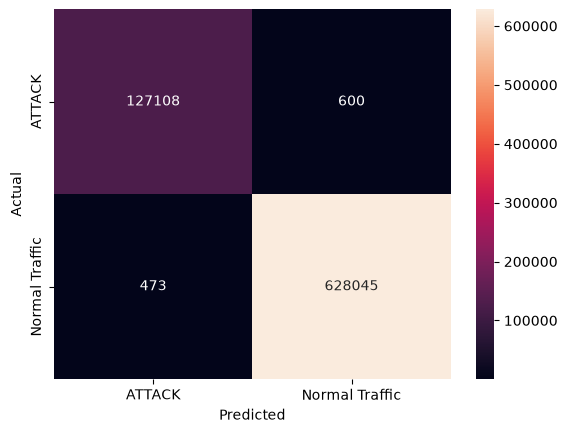

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['ATTACK', 'Normal Traffic'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['ATTACK','Normal Traffic'], yticklabels=['ATTACK','Normal Traffic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(classification_report(y_test2, y_pred2))

                precision    recall  f1-score   support

          Bots       0.85      0.72      0.78       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      0.99      0.99     27208
   Web Attacks       0.99      0.97      0.98       643

      accuracy                           1.00    756226
     macro avg       0.98      0.95      0.96    756226
  weighted avg       1.00      1.00      1.00    756226



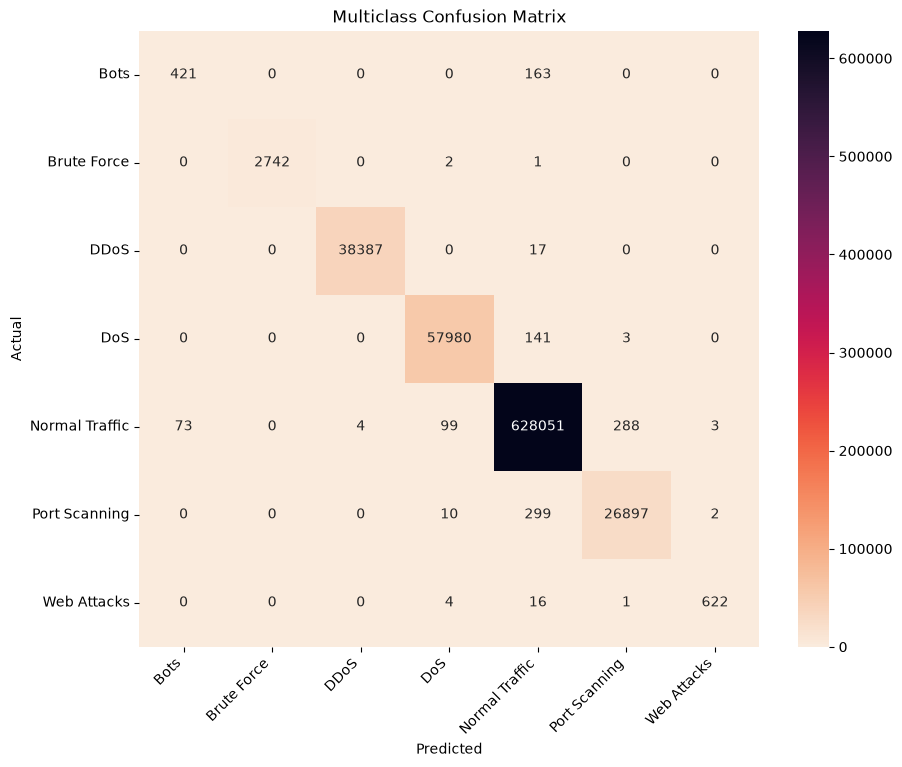

In [20]:
cm2 = confusion_matrix(y_test2, y_pred2, labels=model2.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', 
            xticklabels=model2.classes_, 
            yticklabels=model2.classes_,
            cmap='rocket_r')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

Packet Length Variance         0.084114
Bwd Packet Length Std          0.083918
Packet Length Std              0.050476
Average Packet Size            0.050139
Max Packet Length              0.046934
Bwd Packet Length Mean         0.043777
Subflow Fwd Bytes              0.041430
Total Length of Fwd Packets    0.041106
Fwd Packet Length Max          0.038444
Packet Length Mean             0.037331
Destination Port               0.029173
Init_Win_bytes_backward        0.028492
Fwd IAT Std                    0.023938
Flow IAT Max                   0.023620
Bwd Header Length              0.023095
dtype: float64


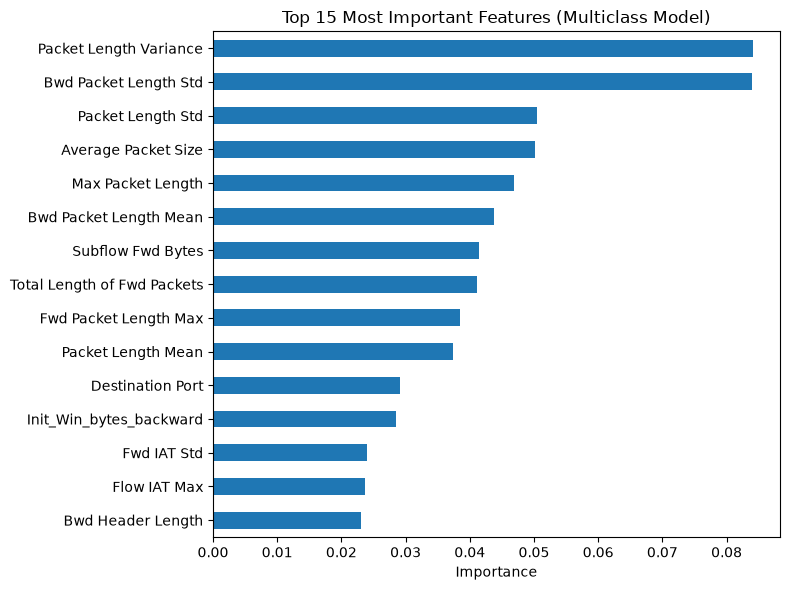

In [21]:
importances2 = pd.Series(model2.feature_importances_, index=X.columns)
top_features2 = importances2.sort_values(ascending=False).head(15)
print(top_features2)

plt.figure(figsize=(8, 6))
top_features2.plot(kind='barh')
plt.title('Top 15 Most Important Features (Multiclass Model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()  # puts the most important feature at the top
plt.tight_layout()
plt.show()

Bwd Packet Length Std          0.108989
Packet Length Variance         0.101280
Packet Length Std              0.069905
Max Packet Length              0.063764
Average Packet Size            0.054995
Bwd Packet Length Mean         0.050924
Packet Length Mean             0.046152
Destination Port               0.029506
Total Length of Fwd Packets    0.028718
Subflow Fwd Bytes              0.026064
Bwd Packet Length Max          0.025964
Fwd IAT Std                    0.025143
Total Fwd Packets              0.021456
Fwd Packet Length Mean         0.019989
Flow IAT Max                   0.019427
dtype: float64


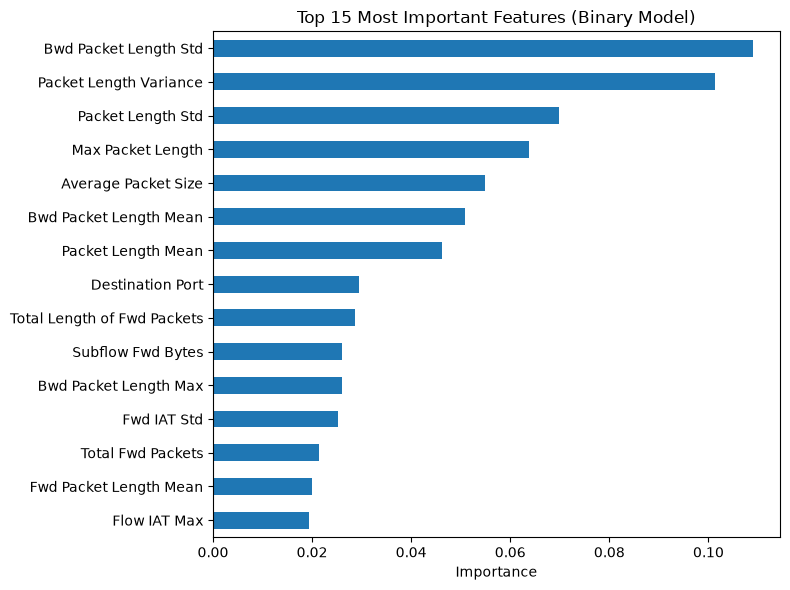

In [22]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)
print(top_features)

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Most Important Features (Binary Model)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()